In [2]:
import torch 
import numpy as np 
import h5py
import os
import IPython.display as ipd
from corpus.speaker_room_dataset import SpeakerRoomDataset
import src.audio_transforms as at
import src.spatial_attn_lightning as binaural_lightning 
import yaml
from tqdm.auto import tqdm
from pathlib import Path
import pandas as pd 
import soxr

%matplotlib inline
import matplotlib.pyplot as plt

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!hostname

node084


# Approach - grid search across spatial configurations 

### Get model 

In [4]:
### Get most recent config
# config_path = "config/binaural_attn/word_task_25p_loc_v07_LN_last_valid_time_no_affine.yaml"
# ckpt_path = "attn_cue_models/word_task_25p_loc_v07_LN_last_valid_time_no_affine/checkpoints/epoch=3-step=49432.ckpt"
# old_style = False
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v07.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v07/checkpoints/epoch=2-step=46074.ckpt"
# old_style = True 

config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['hparas']['batch_size'] = 1 # config['data']['loader']['batch_size'] // args.gpus
config['num_workers'] = 2
config['noise_kwargs']['low_snr'] = 0
config['noise_kwargs']['high_snr'] = 0
# get model input sr for brir resampling
signal_sr = config['audio']['rep_kwargs']['sr']
coch_sr = config['audio']['rep_kwargs']['env_sr']
# cue_duration = 0.5
# n_cue_frames = int(cue_duration * signal_sr)
# config['model']['n_cue_frames'] = n_cue_frames

# config['cue_duration_test'] = True


In [5]:
model = binaural_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config).cuda().eval()
coch_transform = model.coch_gram.cuda()


num_classes={'num_words': 800}


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [6]:
dataset = SpeakerRoomDataset(manifest_path='/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl',
                            excerpt_path='/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl',
                            cue_type='voice_and_location',
                            sr=signal_sr) 
n_egs = 20
dataloader = torch.utils.data.DataLoader(dataset, batch_size=n_egs, shuffle=False, num_workers=config['num_workers'])

audio_transforms_0_db = at.AudioCompose([
                at.AudioToTensor(),
                at.BinauralCombineWithRandomDBSNR(low_snr=0,    # is 0 dB
                                                high_snr=0), # is 0 dB 
                at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02), # 20 * np.log10(0.02/20e-6) = 60 dB SPL 
        ])

audio_transforms_0_db = audio_transforms_0_db.cuda()



In [8]:
import pickle
class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v: k for k, v in class_map.items()}

### Import IRs

In [9]:
room_ix = 0 
test_IR_manifest_dir = Path("/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb")
test_IR_manifest_path = test_IR_manifest_dir / "manifest_brir.pdpkl"
h5_fn = test_IR_manifest_dir / f"room{room_ix:04}.hdf5"
new_room_manifest = pd.read_pickle(test_IR_manifest_path)
only14_manifest = new_room_manifest[(new_room_manifest['index_room'] == room_ix)  & (new_room_manifest['src_dist'] == 1.4)]


In [10]:
def get_brir(azim=None, elev=None, coords=None, h5_fn=None, IR_df=None, out_sr=44_100):
    if coords is not None:
        azim, elev = coords
    df_row = IR_df[(IR_df['src_azim'] == azim) & (IR_df['src_elev'] == elev)]
    brir_ix = df_row['index_brir'].values[0]
    sr_src = df_row['sr'].values[0]
    with h5py.File(h5_fn, 'r') as f:
        brir = f['brir'][brir_ix]
    if out_sr != sr_src:
        brir = soxr.resample(brir.astype(np.float32), sr_src, out_sr)
    return brir

In [11]:
# ## Set signal parameters and target/cue position. 
# RANDOMSEED = 0
# SAMPLERATE = signal_sr
# signal_len = 3 # in seconds

# # cue and target location the same 
# target_azim, target_elev = 0, 0

# # init distractor elevation
# distractor_elev = 0 

# target_brir = get_brir(azim=target_azim, elev=target_elev, h5_fn=h5_fn, IR_df=only14_manifest, out_sr=SAMPLERATE)
# sp_to_target_loc = at.Spatialize(target_brir, model_sr=signal_sr).cuda()

# ## Get example signals 
# ix = 10
# cue, fg, bg, label, confusion = dataset[ix]

# # spatialize cue and fg 
# cue = sp_to_target_loc(cue.unsqueeze(0).cuda())
# fg = sp_to_target_loc(fg.unsqueeze(0).cuda())
# bg = bg.unsqueeze(0).cuda()

# # convert label to tensor
# label = torch.tensor(label).unsqueeze(0).cuda()

# # convert cue to cochleagram 
# cue, _ = audio_transforms_0_db(cue, None)
# cue, _ = coch_transform(cue, None)

# # init search parameters
# azims_to_search = only14_manifest.src_azim.unique()
# losses = np.zeros(len(azims_to_search))
# loss_fn = torch.nn.CrossEntropyLoss()



# best_loss = 0.0
# best_distractor = None
# best_mixture = None
# best_azim = None

# # loop over all azimuths
# for i, azim in enumerate(tqdm(azims_to_search)):
#     brir = get_brir(azim=azim, elev=distractor_elev, h5_fn=h5_fn, IR_df=only14_manifest, out_sr=SAMPLERATE)
#     sp_to_distractor_loc = at.Spatialize(brir, model_sr=signal_sr).cuda()
#     distractor = sp_to_distractor_loc(bg)
#     mixture_wav, _ = audio_transforms_0_db(fg, distractor)
#     mixture, _ = coch_transform(mixture_wav, None)
    
#     with torch.no_grad():
#         pred = model(cue, mixture, None)
#         loss = loss_fn(pred, label)
#     losses[i] = loss.cpu().numpy()

#     if loss > best_loss:
#         best_loss = loss
#         best_distractor = distractor
#         best_mixture = mixture_wav
#         best_azim = azim 

# print(f"Best loss: {best_loss}")
# print(f"Best azimuth (raw): {best_azim}")

# x_bins = np.copy(only14_manifest.src_azim.unique())
# x_bins[x_bins > 180] = x_bins[x_bins > 180] - 360
# new_order = np.argsort(x_bins)
# x_bins = x_bins[new_order]
# plt.plot(x_bins, losses[new_order])

# plt.title("Loss vs. Azimuth")
# plt.xlabel("Azimuth (degrees)")
# plt.ylabel("Loss")

In [15]:
## Set signal parameters and target/cue position. 
RANDOMSEED = 0
SAMPLERATE = signal_sr
signal_len = 3 # in seconds

# cue and target location the same 
target_azim, target_elev = 0, 0

# init distractor elevation
distractor_elev = 0 

target_brir = get_brir(azim=target_azim, elev=target_elev, h5_fn=h5_fn, IR_df=only14_manifest, out_sr=SAMPLERATE)
sp_to_target_loc = at.Spatialize(target_brir, model_sr=signal_sr).cuda()


n_to_run = 500
# init search parameters
azims_to_search = only14_manifest.src_azim.unique()
losses = np.zeros((n_to_run, len(azims_to_search)))
loss_fn = torch.nn.CrossEntropyLoss(reduction='none')



# loop over all azimuths
for i, azim in enumerate(tqdm(azims_to_search)):
    brir = get_brir(azim=azim, elev=distractor_elev, h5_fn=h5_fn, IR_df=only14_manifest, out_sr=SAMPLERATE)
    sp_to_distractor_loc = at.Spatialize(brir, model_sr=signal_sr).cuda()

    for j, batch in enumerate(tqdm(dataloader, total= n_to_run // n_egs, leave=False)):
        # get batch for adding to losses 
        start = j * n_egs
        end = (j+1) * n_egs

        # spatialize cue and fg 
        cue, fg, bg, label, confusion = batch

        cue = sp_to_target_loc(cue.cuda())
        fg = sp_to_target_loc(fg.cuda())
        bg = sp_to_distractor_loc(bg.cuda()) 
        label = label.cuda()

        cue, _ = audio_transforms_0_db(cue, None)

        mixture_wav, _ = audio_transforms_0_db(fg, bg)
        cue, mixture = coch_transform(cue, mixture_wav)
        
        with torch.no_grad():
            pred = model(cue, mixture, None)
            loss = loss_fn(pred, label)
        losses[start:end,i] = loss.cpu().numpy()
        
        if (j+1) * n_egs >= n_to_run:
            break
    break

#     if loss > best_loss:
#         best_loss = loss
#         best_distractor = distractor
#         best_mixture = mixture_wav
#         best_azim = azim 

# print(f"Best loss: {best_loss}")
# print(f"Best azimuth (raw): {best_azim}")

# x_bins = np.copy(only14_manifest.src_azim.unique())
# x_bins[x_bins > 180] = x_bins[x_bins > 180] - 360
# new_order = np.argsort(x_bins)
# x_bins = x_bins[new_order]
# plt.plot(x_bins, losses[new_order])

# plt.title("Loss vs. Azimuth")
# plt.xlabel("Azimuth (degrees)")
# plt.ylabel("Loss")

  0%|          | 0/72 [01:37<?, ?it/s]


[  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175
 180 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265
 270 275 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355]


array([-175, -170, -165, -160, -155, -150, -145, -140, -135, -130, -125,
       -120, -115, -110, -105, -100,  -95,  -90,  -85,  -80,  -75,  -70,
        -65,  -60,  -55,  -50,  -45,  -40,  -35,  -30,  -25,  -20,  -15,
        -10,   -5,    0,    5,   10,   15,   20,   25,   30,   35,   40,
         45,   50,   55,   60,   65,   70,   75,   80,   85,   90,   95,
        100,  105,  110,  115,  120,  125,  130,  135,  140,  145,  150,
        155,  160,  165,  170,  175,  180])

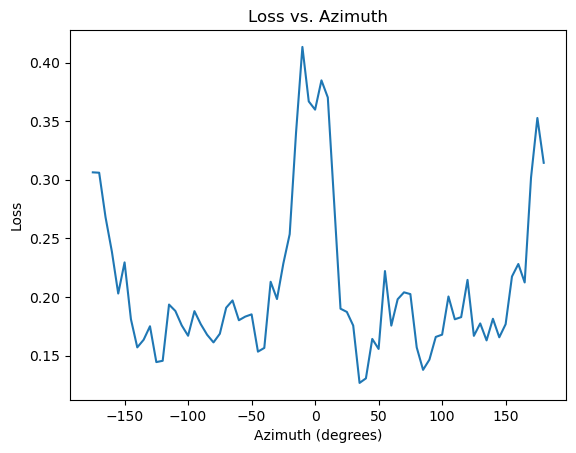

In [ ]:
plt.figure()
plt.title("Loss vs. Azimuth")
plt.xlabel("Azimuth (degrees)")
plt.ylabel("Loss")

x_bins = np.copy(only14_manifest.src_azim.unique())
x_bins[x_bins > 180] = x_bins[x_bins > 180] - 360
new_order = np.argsort(x_bins)
x_bins = x_bins[new_order]
# re order losses to match x_bins

plt.plot(x_bins, losses[new_order])
# arange x ticks plot given azimuths are polar coordinates 
print(only14_manifest.src_azim.unique())
x_bins
# plt.xticks(x_bins[::11], x_bins[::11]);
# x_bins[::9]


In [ ]:
ipd.display(ipd.Audio(fg.cpu().numpy().squeeze(), rate=SAMPLERATE, normalize=False))
# ipd.display(ipd.Audio(distractor_eg_fin.cpu().numpy().squeeze(), rate=SAMPLERATE))
ipd.display(ipd.Audio(best_mixture.cpu().numpy().squeeze(), rate=SAMPLERATE, normalize=False))
print(ix_to_word[label.item()])

continued
